In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fahim\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv(r"C:\Users\fahim\OneDrive\Documents\FUTURE_ML_03\resume.csv")

In [3]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [5]:
df.shape

(2484, 4)

In [6]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [7]:
print("Enter the Job Description:")
job_description=input()

Enter the Job Description:


 job_description = """ We are hiring an Information Technology professional with skills in Python, Java, SQL, HTML, CSS, JavaScript, Machine Learning, Data Analysis, Git, Problem Solving, Communication, and Teamwork. """


In [19]:
df.shape

(2484, 4)

In [21]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [23]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['Clean_Resume'] = df['Resume_str'].apply(clean_text)

df[['Resume_str', 'Clean_Resume']].head()

,Resume_str,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [24]:
job_description = """
We are hiring an Information Technology professional with skills in Python,
Java, SQL, HTML, CSS, JavaScript, Machine Learning,
Data Analysis, Git, Problem Solving, Communication, and Teamwork.
"""

In [25]:
# Combine job description with all resumes
documents = [job_description] + df['Clean_Resume'].tolist()

# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

# Calculate cosine similarity
similarity_scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()

# Add similarity scores to the dataframe
df['Match_Score'] = similarity_scores

# Rank candidates
ranked_df = df.sort_values(by='Match_Score', ascending=False)

# Display top 10 candidates
ranked_df[['ID', 'Category', 'Match_Score']].head(10)

,ID,Category,Match_Score
297,83816738,INFORMATION-TECHNOLOGY,0.140099
1932,33141415,CONSTRUCTION,0.120457
926,62994611,AGRICULTURE,0.115059
1303,42156237,DIGITAL-MEDIA,0.113837
2184,39247950,BANKING,0.112645
1218,21156767,CONSULTANT,0.109726
1742,51588273,ENGINEERING,0.109365
1762,12011623,ENGINEERING,0.104004
314,10641230,INFORMATION-TECHNOLOGY,0.102806
1111,43311839,CONSULTANT,0.101986


In [28]:
# Convert similarity score to percentage
ranked_df['Match_Percentage'] = (ranked_df['Match_Score'] * 100).round(2)

# Assign rank
ranked_df['Rank'] = range(1, len(ranked_df) + 1)

# Display top 10
ranked_df[['Rank', 'ID', 'Category', 'Match_Percentage']].head(10)

,Rank,ID,Category,Match_Percentage
297,1,83816738,INFORMATION-TECHNOLOGY,14.01
1932,2,33141415,CONSTRUCTION,12.05
926,3,62994611,AGRICULTURE,11.51
1303,4,42156237,DIGITAL-MEDIA,11.38
2184,5,39247950,BANKING,11.26
1218,6,21156767,CONSULTANT,10.97
1742,7,51588273,ENGINEERING,10.94
1762,8,12011623,ENGINEERING,10.40
314,9,10641230,INFORMATION-TECHNOLOGY,10.28
1111,10,43311839,CONSULTANT,10.20


In [29]:
max_score = ranked_df['Match_Score'].max()

ranked_df['Match_Percentage'] = (
    ranked_df['Match_Score'] / max_score * 100
).round(2)

ranked_df[['Rank', 'ID', 'Category', 'Match_Percentage']].head(10)

,Rank,ID,Category,Match_Percentage
297,1,83816738,INFORMATION-TECHNOLOGY,100.00
1932,2,33141415,CONSTRUCTION,85.98
926,3,62994611,AGRICULTURE,82.13
1303,4,42156237,DIGITAL-MEDIA,81.25
2184,5,39247950,BANKING,80.40
1218,6,21156767,CONSULTANT,78.32
1742,7,51588273,ENGINEERING,78.06
1762,8,12011623,ENGINEERING,74.24
314,9,10641230,INFORMATION-TECHNOLOGY,73.38
1111,10,43311839,CONSULTANT,72.80


In [33]:
skill_list = [
    "python", "java", "sql", "html", "css",
    "javascript", "machine learning", "data analysis",
    "git", "communication", "excel", "power bi",
    "tableau", "aws", "azure", "docker",
    "kubernetes", "tensorflow", "pandas", "numpy"
]

required_skills = [
    skill for skill in skill_list
    if skill.lower() in job_description.lower()
]

print("Required Skills:", required_skills)

Required Skills: ['python', 'java', 'sql', 'html', 'css', 'javascript', 'machine learning', 'data analysis', 'git', 'communication']


In [35]:
def find_missing_skills(resume):
    resume = resume.lower()
    present = [skill for skill in required_skills if skill in resume]
    missing = [skill for skill in required_skills if skill not in resume]
    return present, missing

In [37]:
def recommendation(score):
    if score >= 80:
        return "Highly Recommended"
    elif score >= 60:
        return "Recommended"
    elif score >= 40:
        return "Consider"
    else:
        return "Low Match"

ranked_df["Recommendation"] = ranked_df["Match_Percentage"].apply(recommendation)

In [39]:
top5 = ranked_df[['Rank','ID','Category','Match_Percentage','Recommendation']].head(5)

print("Top 5 Matching Candidates")
print(top5)

Top 5 Matching Candidates
      Rank        ID                Category  Match_Percentage  \
297      1  83816738  INFORMATION-TECHNOLOGY            100.00   
1932     2  33141415            CONSTRUCTION             85.98   
926      3  62994611             AGRICULTURE             82.13   
1303     4  42156237           DIGITAL-MEDIA             81.25   
2184     5  39247950                 BANKING             80.40   

          Recommendation  
297   Highly Recommended  
1932  Highly Recommended  
926   Highly Recommended  
1303  Highly Recommended  
2184  Highly Recommended  


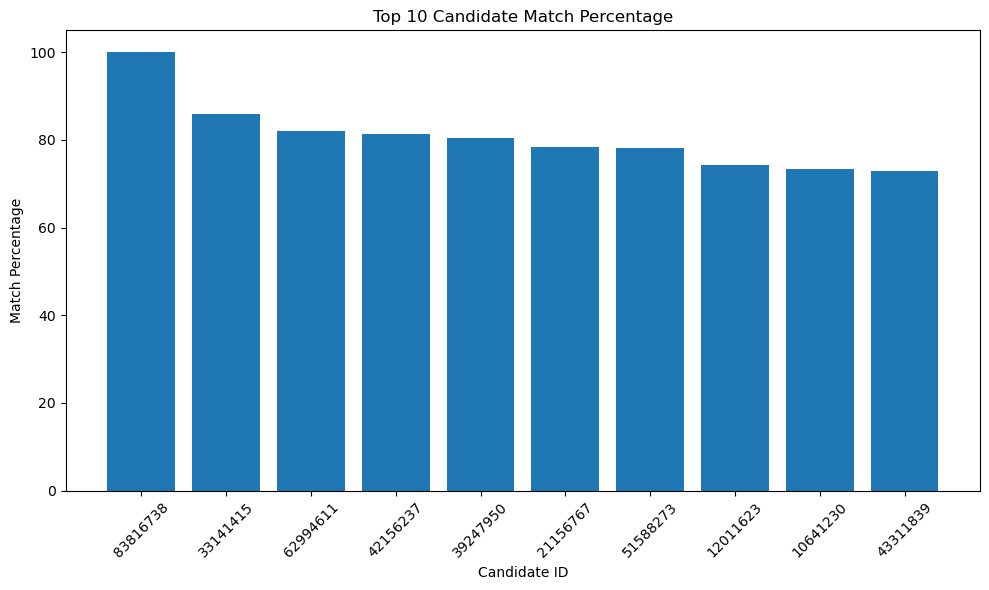

In [41]:
import matplotlib.pyplot as plt

top10 = ranked_df.head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['ID'].astype(str), top10['Match_Percentage'])
plt.title("Top 10 Candidate Match Percentage")
plt.xlabel("Candidate ID")
plt.ylabel("Match Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
ranked_df[['Rank', 'ID', 'Category', 'Match_Percentage']].to_csv(
    "ranked_candidates.csv",
    index=False
)

In [45]:
skill_gap = ranked_df.head(5).copy()

skill_gap["Skills Found"], skill_gap["Missing Skills"] = zip(
    *skill_gap["Clean_Resume"].apply(find_missing_skills)
)

skill_gap[['Rank', 'ID', 'Category', 'Skills Found', 'Missing Skills']].to_csv(
    "skill_gap_analysis.csv",
    index=False
)

In [48]:
import os
print(os.path.abspath("ranked_candidates.csv"))

C:\Users\fahim\ranked_candidates.csv


In [50]:
import os
print(os.path.abspath("skill_gap_analysis.csv"))


C:\Users\fahim\skill_gap_analysis.csv
